In [16]:
!pip install duckdb numpy pandas matplotlib

  Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.2.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 45.0 MB/s  0:00:00m0:00:01
Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 61.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.0 MB/s  0:00:00
Using cached pillow-12.2.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (7.1 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


## Connect DuckDB to the S3 path as a database

In [3]:
import duckdb
 
con = duckdb.connect()
 
# httpfs provides S3/HTTP(S) support in DuckDB
con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")
 
# Point DuckDB at the CEPH endpoint instead of AWS, and disable request signing
# since this is a public/anonymous bucket.
con.execute("""
    SET s3_endpoint = 'rice1.osn.mghpcc.org';
    SET s3_url_style = 'path';     -- CEPH typically needs path-style, not virtual-hosted
    SET s3_use_ssl = true;
    SET s3_region = 'us-east-1';   -- value usually ignored by CEPH, but DuckDB requires it set
""")


# Create a View to Make It Easier to Query

In [11]:
con.execute("""
    CREATE OR REPLACE VIEW era5_land AS
    SELECT *
    FROM read_parquet(
        's3://sdoh-public/era5-land/parquet/*/*/*/*.parquet',
        hive_partitioning = true
    )
""")
result = con.execute("SELECT STATE, YEAR, COUNT(*) AS n FROM era5_land GROUP BY 1,2 ORDER BY 1,2").df()
print(result)


  STATE  YEAR      n
0    IL  2024  23424
1    IL  2025  23360
2    IL  2026  11264


# Create View On Station Data

In [12]:
con.execute("""
    CREATE OR REPLACE VIEW stations AS
    SELECT *
    FROM read_csv('s3://sdoh-public/pri_data/stations.csv')
""")

df = con.execute("SELECT * FROM stations LIMIT 10").df()
print(df)


   ID         Site Name        Lat        Lon Project
0   2   IVA Rain Gage 2  40.477878 -89.765486     IVA
1   3   IVA Rain Gage 3  40.482442 -89.625972     IVA
2   4   IVA Rain Gage 4  40.408206 -89.911394     IVA
3   6   IVA Rain Gage 6  40.380053 -89.716567     IVA
4   7   IVA Rain Gage 7  40.406719 -89.624906     IVA
5   8   IVA Rain Gage 8  40.353081 -90.021661     IVA
6   9   IVA Rain Gage 9  40.313019 -89.901853     IVA
7  10  IVA Rain Gage 10  40.332497 -89.814583     IVA
8  11  IVA Rain Gage 11  40.333697 -89.734653     IVA
9  12  IVA Rain Gage 12  40.311847 -89.604544     IVA


# Join Stations and ERA5-Land Readings

In [14]:
con.execute("""
SELECT * FROM era5_land JOIN stations on era5_land.station_id = stations.id 
LIMIT 10
""").df()

,station_id,station_name,date,t2m_max_c,t2m_min_c,t2m_mean_c,d2m_mean_c,precip_total_mm,MONTH,STATE,YEAR,ID,Site Name,Lat,Lon,Project
0,10,IVA Rain Gage 10,2024-01-01,2.041,-3.057,-0.814,-5.830,0.001000,01,IL,2024,10,IVA Rain Gage 10,40.332497,-89.814583,IVA
1,10,IVA Rain Gage 10,2024-01-02,4.932,-3.784,-0.513,-4.301,0.002000,01,IL,2024,10,IVA Rain Gage 10,40.332497,-89.814583,IVA
2,10,IVA Rain Gage 10,2024-01-03,1.726,-3.534,-0.561,-3.674,0.030000,01,IL,2024,10,IVA Rain Gage 10,40.332497,-89.814583,IVA
3,10,IVA Rain Gage 10,2024-01-04,3.284,-3.553,0.132,-4.401,0.008000,01,IL,2024,10,IVA Rain Gage 10,40.332497,-89.814583,IVA
4,10,IVA Rain Gage 10,2024-01-05,3.465,-3.545,-0.613,-4.549,1.403000,01,IL,2024,10,IVA Rain Gage 10,40.332497,-89.814583,IVA
5,10,IVA Rain Gage 10,2024-01-06,2.638,-0.803,0.700,-0.352,4.182000,01,IL,2024,10,IVA Rain Gage 10,40.332497,-89.814583,IVA
6,10,IVA Rain Gage 10,2024-01-07,3.058,-1.204,0.303,-2.410,0.913000,01,IL,2024,10,IVA Rain Gage 10,40.332497,-89.814583,IVA
7,10,IVA Rain Gage 10,2024-01-08,4.291,-1.953,0.963,-1.886,6.021000,01,IL,2024,10,IVA Rain Gage 10,40.332497,-89.814583,IVA
8,10,IVA Rain Gage 10,2024-01-09,1.095,0.433,0.845,0.400,22.686001,01,IL,2024,10,IVA Rain Gage 10,40.332497,-89.814583,IVA
9,10,IVA Rain Gage 10,2024-01-10,1.513,-4.359,-1.101,-3.980,0.564000,01,IL,2024,10,IVA Rain Gage 10,40.332497,-89.814583,IVA


# Make Some Visualizations!

In [17]:
import matplotlib.pyplot as plt

df = con.execute("""
    SELECT
        CAST(date AS DATE) AS date,
        YEAR,
        MONTH,
        precip_total_mm
    FROM era5_land
    WHERE station_id = '10'
    ORDER BY date
""").df()

df.head()

,date,YEAR,MONTH,precip_total_mm
0,2024-01-01,2024,01,0.001
1,2024-01-02,2024,01,0.002
2,2024-01-03,2024,01,0.030
3,2024-01-04,2024,01,0.008
4,2024-01-05,2024,01,1.403


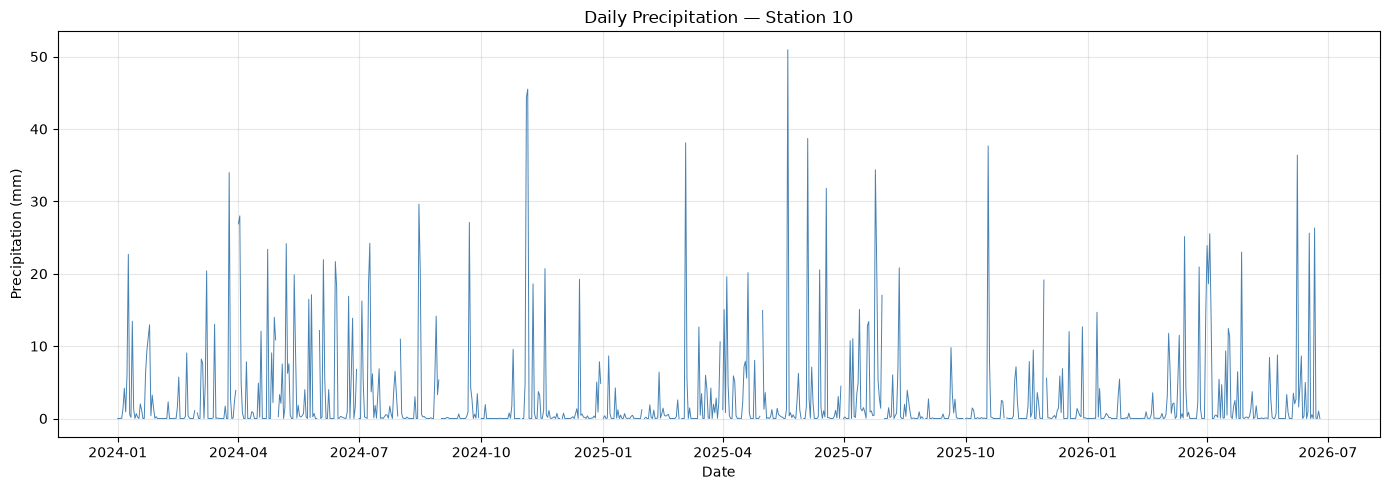

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['date'], df['precip_total_mm'], linewidth=0.7, color='steelblue')
ax.set_title('Daily Precipitation — Station 10')
ax.set_xlabel('Date')
ax.set_ylabel('Precipitation (mm)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

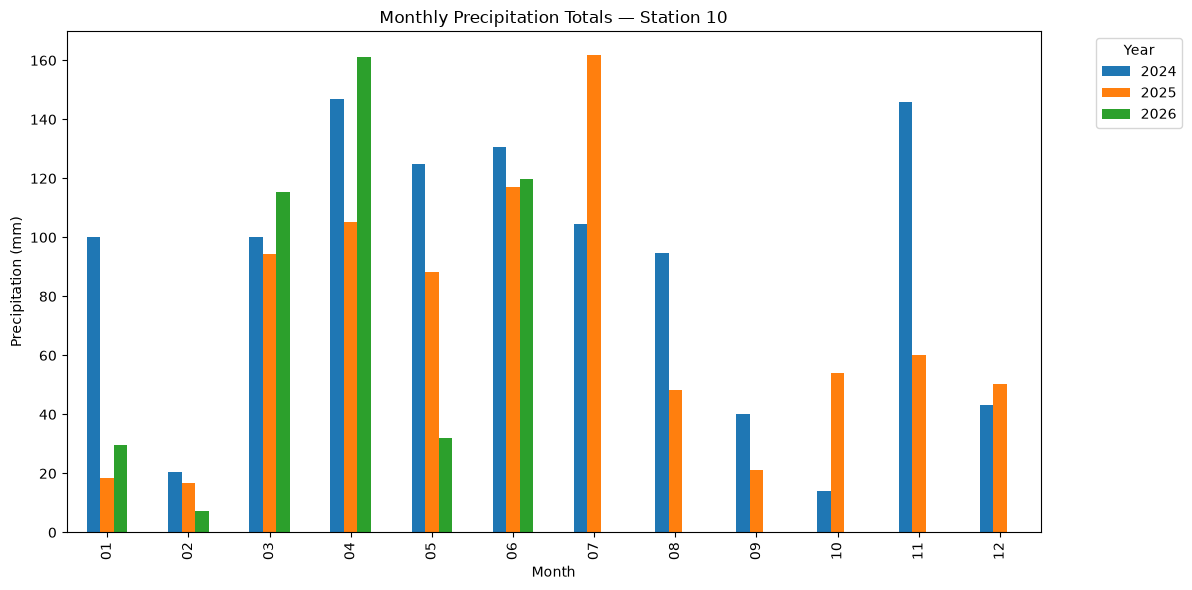

In [19]:
monthly = con.execute("""
    SELECT
        YEAR,
        MONTH,
        SUM(precip_total_mm) AS monthly_precip_mm
    FROM era5_land
    WHERE station_id = '10'
    GROUP BY YEAR, MONTH
    ORDER BY YEAR, MONTH
""").df()

pivot = monthly.pivot(index='MONTH', columns='YEAR', values='monthly_precip_mm')

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='bar', ax=ax)
ax.set_title('Monthly Precipitation Totals — Station 10')
ax.set_ylabel('Precipitation (mm)')
ax.set_xlabel('Month')
ax.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

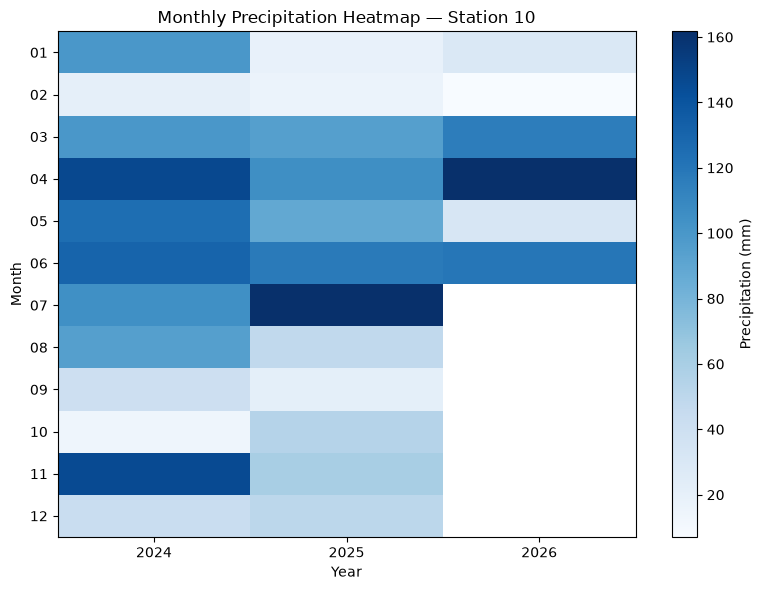

In [20]:
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, aspect='auto', cmap='Blues')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Year')
ax.set_ylabel('Month')
ax.set_title('Monthly Precipitation Heatmap — Station 10')
fig.colorbar(im, label='Precipitation (mm)')
plt.tight_layout()
plt.show()